In [333]:
from scipy.io import wavfile
import numpy as np


In [334]:
import matplotlib.pyplot as plt
from pathlib import Path
import glob

In [335]:
# Find all wav files
wav_files = sorted(glob.glob('wav/*.wav'))
print(f"Found {len(wav_files)} wav files:")
for f in wav_files:
    print(f"  {f}")

Found 3 wav files:
  wav/43995e6_32_remez.wav
  wav/87a7062_35_32_15_remez.wav
  wav/b648783_47_cascade_47.wav


In [336]:
# Process each wav file and compute averaged frequency response
SAMPLE_RATE = 96000
FFT_SIZE = 16384
CHANNEL_IDX = 7  # 8th channel (0-indexed)

results = {}

for wav_file in wav_files:
    # Read wav file
    rate, data = wavfile.read(wav_file)
    
    # Extract channel 7 (8th channel)
    if len(data.shape) == 1:
        print(f"Warning: {wav_file} is mono, skipping")
        continue
    
    channel_data = data[:, CHANNEL_IDX]
    
    # Compute FFTs every 16384 samples
    num_ffts = len(channel_data) // FFT_SIZE
    
    if num_ffts == 0:
        print(f"Warning: {wav_file} too short, skipping")
        continue
    
    # Accumulate FFT magnitudes
    fft_sum = np.zeros(FFT_SIZE // 2 + 1)
    
    for i in range(num_ffts):
        start_idx = i * FFT_SIZE
        end_idx = start_idx + FFT_SIZE
        segment = channel_data[start_idx:end_idx]
        
        # Compute FFT
        fft_result = np.fft.rfft(segment)
        magnitude = np.abs(fft_result)
        fft_sum += magnitude
    
    # Average the FFTs
    avg_magnitude = fft_sum / num_ffts
    
    # Convert to dB
    magnitude_db = 20 * np.log10(avg_magnitude + 1e-10)
    
    # Normalize to 0 dB at peak
    magnitude_db -= np.max(magnitude_db)
    
    # Frequency axis
    freqs = np.fft.rfftfreq(FFT_SIZE, 1/rate)
    
    # Store results
    filename = Path(wav_file).stem
    results[filename] = {
        'freqs': freqs,
        'magnitude_db': magnitude_db,
        'num_ffts': num_ffts
    }
    
    print(f"Processed {filename}: {num_ffts} FFTs averaged")

Processed 43995e6_32_remez: 11 FFTs averaged
Processed 87a7062_35_32_15_remez: 11 FFTs averaged
Processed b648783_47_cascade_47: 11 FFTs averaged


In [337]:
import re

# Parse coefficient files to extract theoretical filter coefficients
def parse_coef_file(filepath, coef_name):
    """Extract coefficients from .xc file for a given array name (debug arrays are decimal)"""
    with open(filepath, 'r') as f:
        content = f.read()

    # Find the array definition
    pattern = rf'const int {coef_name}\[\d+\] = \{{([^}}]+)\}};'
    match = re.search(pattern, content, re.MULTILINE | re.DOTALL)

    if not match:
        return None

    # Extract decimal values (debug arrays are already in decimal, not hex)
    decimal_values = re.findall(r'-?\d+', match.group(1))

    # Convert to integers
    coefs = [int(val) for val in decimal_values]

    return np.array(coefs)

# Mapping of wav files to coefficient files and array names
filter_configs = {
    '43995e6_32_remez': {
        'coef_file': 'coefs/43995e6_32_remez.xct',
        'coef_name_2': 'g_second_stage_fir32_43kHz_debug',
        'coef_name_3': None,
        'num_taps': 32
    },
    '87a7062_35_32_15_remez': {
        'coef_file': 'coefs/87a7062_35_32_15_remez.xct',
        'coef_name_2': 'g_second_stage_fir35_32kHz_debug',
        'coef_name_3': None,
        'num_taps': 35
    },
    'b648783_47_cascade_47': {
        'coef_file': 'coefs/b648783_47_cascade_47.xct',
        'coef_name_2': 'g_second_to_third_fir47_48kHz_debug',
        'coef_name_3': 'g_third_to_output_fir47_40kHz_debug',
        'num_taps': 48
    },
}

measured_to_theoretical_mapping = {
    '43995e6_32_remez.wav': '43995e6_32_remez',
    '87a7062_35_32_15_remez.wav': '87a7062_35_32_15_remez',
    'b648783_47_cascade_47.wav': 'b648783_47_cascade_47'
}

# Load theoretical coefficients
theoretical_filters = {}
for filter_name, config in filter_configs.items():
    coefs_2 = parse_coef_file(config['coef_file'], config['coef_name_2'])
    coefs_3 = None
    if config['coef_name_3']:
        coefs_3 = parse_coef_file(config['coef_file'], config['coef_name_3'])

    if (coefs_2 is not None) and (coefs_3 is not None):
        # Convolution of two filters simulates the cascade.
        # Stage 3 runs at half the rate of Stage 2. To combine them into a single effective
        # filter at the input rate, we must upsample Stage 3 coefficients by 2.
        # H_total(z) = H2(z) * H3(z^2)
        coefs_3_upsampled = np.zeros(len(coefs_3) * 2)
        coefs_3_upsampled[::2] = coefs_3

        theoretical_filters[filter_name] = np.convolve(coefs_2, coefs_3_upsampled)
        print(f"Loaded cascaded {filter_name}: {len(coefs_2)} + {len(coefs_3)} coefficients -> {len(theoretical_filters[filter_name])} taps (upsampled)")
    elif coefs_2 is not None:
        theoretical_filters[filter_name] = coefs_2
        print(f"Loaded {filter_name}: {len(coefs_2)} coefficients")
    else:
        print(f"Warning: Could not load {filter_name}")

Loaded 43995e6_32_remez: 32 coefficients
Loaded 87a7062_35_32_15_remez: 36 coefficients
Loaded cascaded b648783_47_cascade_47: 48 + 48 coefficients -> 143 taps (upsampled)


In [338]:
# Compute theoretical frequency responses at 384 kHz (stage 2 input rate)
STAGE2_INPUT_RATE = 384000  # Hz
FFT_SIZE_THEORY = 8192

theoretical_responses = {}

for filter_name, coefs in theoretical_filters.items():
    # Zero-pad to FFT size
    padded = np.zeros(FFT_SIZE_THEORY)
    padded[:len(coefs)] = coefs

    # Compute FFT
    fft_result = np.fft.rfft(padded)
    magnitude = np.abs(fft_result)

    # Convert to dB and normalize
    magnitude_db = 20 * np.log10(magnitude + 1e-10)
    magnitude_db -= np.max(magnitude_db)

    # Frequency axis
    freqs = np.fft.rfftfreq(FFT_SIZE_THEORY, 1/STAGE2_INPUT_RATE)

    theoretical_responses[filter_name] = {
        'freqs': freqs,
        'magnitude_db': magnitude_db
    }

print(f"Computed theoretical responses for {len(theoretical_responses)} filters")

Computed theoretical responses for 3 filters


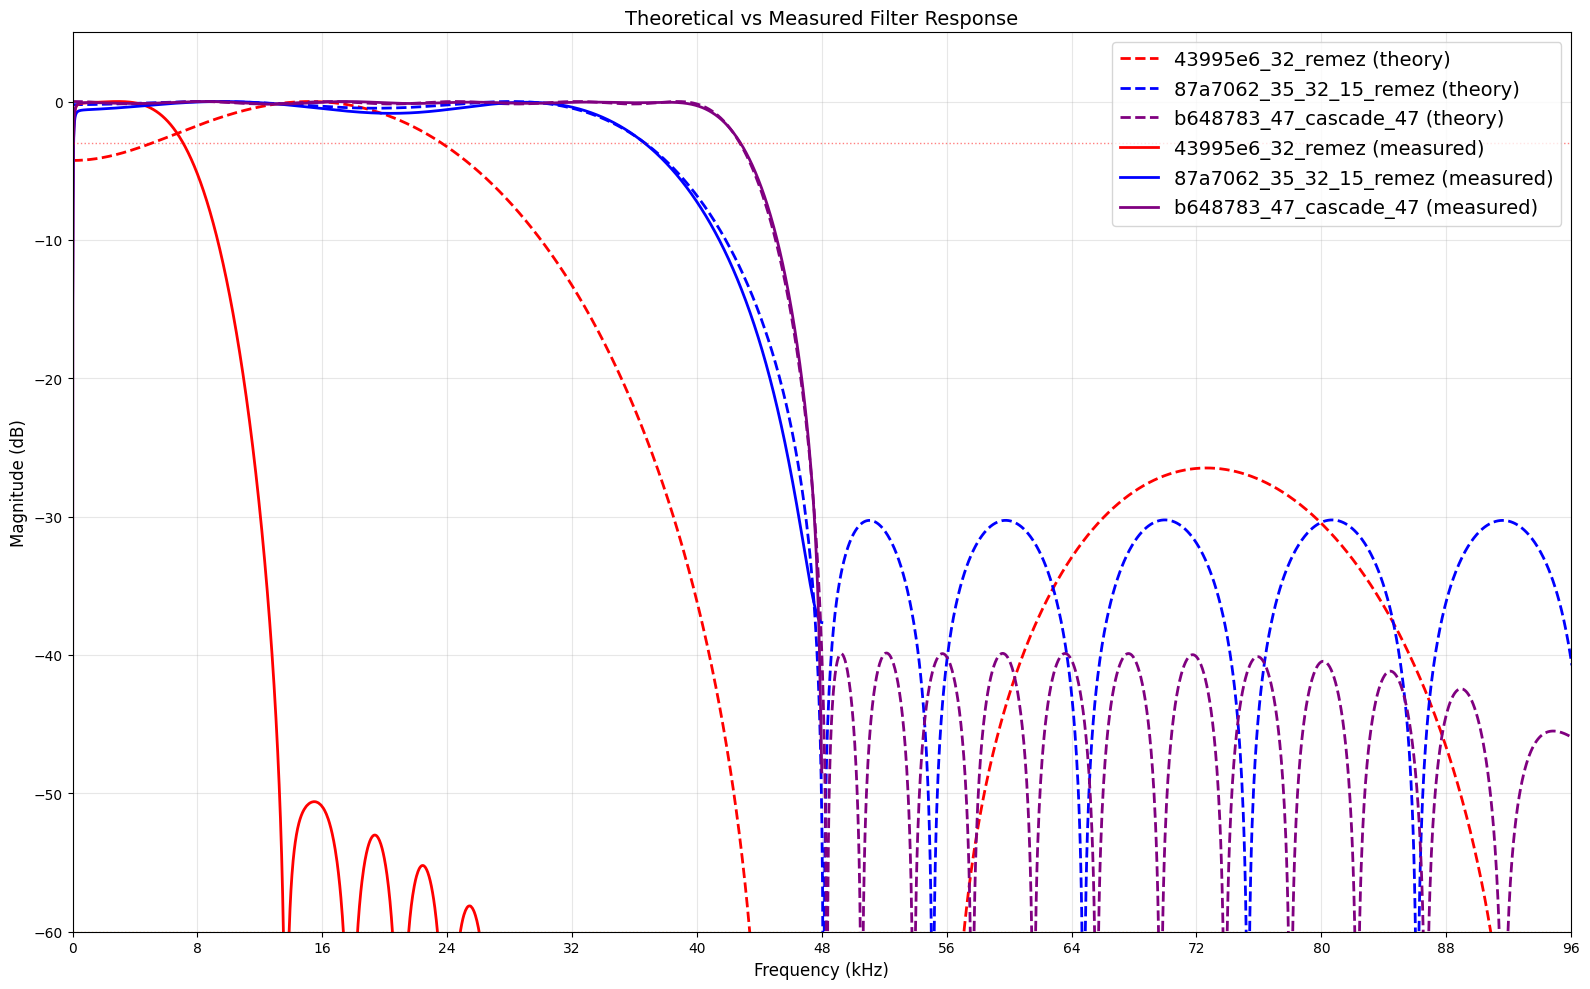

In [339]:
# Plot theoretical vs measured responses on single graph
plt.figure(figsize=(16, 10))

# Define colors for theoretical filters
colors_theoretical = {
    '43995e6_32_remez': 'red',
    '87a7062_35_32_15_remez': 'blue',
    '50eb179_31_cascade_31':'darkgreen',
    'b648783_47_cascade_47':'purple',
}

# Create color mapping for measured filters
other_colors = ['darkgreen', 'purple', 'orange', 'brown', 'pink', 'olive', 'cyan', 'magenta']
other_color_idx = 0
colors_measured = {}

for filter_name in results.keys():
    if filter_name in theoretical_responses:
        # Use same color as theoretical counterpart
        colors_measured[filter_name] = colors_theoretical.get(filter_name, 'gray')
    else:
        # Use a different color from the palette
        colors_measured[filter_name] = other_colors[other_color_idx % len(other_colors)]
        other_color_idx += 1

# Plot theoretical responses (dashed lines)
for filter_name, data in theoretical_responses.items():
    color = colors_theoretical.get(filter_name, 'gray')
    plt.plot(data['freqs'] / 1000, data['magnitude_db'],
             label=f"{filter_name} (theory)", linewidth=2, color=color, linestyle='--')

# Plot measured responses (solid lines)
for filter_name, data in results.items():
    color = colors_measured[filter_name]
    plt.plot(data['freqs'] / 1000, data['magnitude_db'],
             label=f"{filter_name} (measured)", linewidth=2, color=color, linestyle='-')

plt.xlabel('Frequency (kHz)', fontsize=12)
plt.ylabel('Magnitude (dB)', fontsize=12)
plt.title('Theoretical vs Measured Filter Response', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=14)
plt.xlim(0, 96)
plt.ylim(-60, 5)
plt.xticks(np.arange(0, 97, 8))
plt.axhline(y=-3, color='r', linestyle=':', alpha=0.5, linewidth=1)
plt.axhline(y=-60, color='orange', linestyle=':', alpha=0.5, linewidth=1)
plt.tight_layout()
plt.show()